<a href="https://colab.research.google.com/github/namithatholasi/undergrad_ml_assignments/blob/main/Demand_Estimation_Lab_Notebook3_PricingAnalyst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Demand Estimation and Market Analysis: Air Fryers

# Names/Computing IDS: Clairice Lou (pnu9pt), Namitha Tholasi (cku5zp), Ngan Huynh (dfe4yx), Yannely Escalante Ruiz (usw5zk)

In this lab, you will study the market for air fryers using brand-year data aggregated from Amazon purchases. The goal is to move from descriptive analysis to a simple demand model, and then use that model to infer markups and unit costs.

Use the cleaned file:

```python
air_fryers_clean_brand_year.csv
```

This file keeps the top 10 air-fryer brands from 2019-2023 and drops the long tail of very small brands. The variable `brand_share` has already been recomputed within this cleaned name-brand market, so shares sum to 1 within each year.

## Data

Each row is one brand in one year.

Important columns:

- `year`: calendar year
- `brand`: air-fryer brand
- `purchase_count`: number of purchases by that brand in that year
- `product_count`: number of distinct products observed for that brand-year
- `avg_price`: average price for that brand-year
- `avg_rating`: average review rating for that brand-year
- `brand_share`: purchase share within the cleaned air-fryer market in that year
- `log_brand_share`: `np.log(brand_share)`, already computed for convenience
- `compact_share`, `dual_basket_share`, `oven_style_share`, `rotisserie_share`, `window_share`: product characteristic shares for the brand-year

The original lecture wrote the demand equation using an outside option:

$$
\log(s_{bt}) - \log(s_{ot}).
$$

For this cleaned dataset, we dropped the nuisance long-tail brands instead of treating them as an outside option. You should therefore use:

$$
y_{bt} = \log(s_{bt})
$$

as the outcome and include **year dummies**. The year dummies absorb the year-specific denominator of the multinomial logit share equation. This keeps the assignment focused on the cleaned name-brand market.

## Results Expectations! (Final Part)

Submit a GitHub repo containing:

1. A notebook corresponding to the data analyst work, including the code and graphs, explicitly answering the questions above in text markdown chunks
2. A notebook corresponding to the data scientist work, including the code and graphs, explicitly answering the questions above in text markdown chunks
3. A notebook corresponding to the pricing analyst work, including the code and graphs, explicitly answering the questions above in text markdown chunks
4. A short presentation of your findings, about 5-8 slides.

Your presentation should be written as if you were giving market intelligence to a business audience. It should include:

- A short description of the air-fryer market
- A few plots showing prices, ratings, and market shares over time
- A short explanation of the demand model (multinomial logistic regression, estimated by linear regression on log market share)
- The estimated price coefficient and why its sign matters
- A discussion of the most important product features
- Estimated unit costs, markups, and share-weighted profits
- A conclusion about the brands' relative positions in the market

Do not fill slides with raw code. Use your code to produce clear tables and figures, then explain the market story in words.

## 3. Strategy: Costs, Markups, and Profit

Now use the demand estimate to infer market fundamentals.

The price coefficient is constant across brands and years, $\hat{\beta}_{price}$.

For each brand-year, compute the slope of demand with respect to price as:

$$
\hat{s}'_{bt}(p_{bt}) = \hat{\beta}_{price} s_{bt}(1 - s_{bt}).
$$

Then estimate unit cost, or marginal cost, using the firm's first-order pricing condition:

$$
\hat{c}_{bt} = p_{bt} + \frac{s_{bt}}{\hat{s}'_{bt}(p_{bt})}.
$$

Because $\hat{\beta}_{price}$ should be negative, $\hat{s}'_{bt}(p_{bt})$ should also be negative. If your price coefficient is positive, stop and debug your model before interpreting costs.

Compute:

- `demand_slope`: $\hat{s}'_{bt}(p_{bt})$
- `unit_cost`: $\hat{c}_{bt}$
- `markup`: $m_{bt} = p_{bt} - \hat{c}_{bt}$
- `average_profit`: $s_{bt} \times m_{bt}$

Here `average_profit` is a share-weighted profit index, not total dollars of profit. It is useful for comparing brand-years inside this cleaned market.

Questions:

1. What are the average unit costs and markups for each brand over the years?
2. Are any inferred unit costs negative? If so, what might that mean?
3. Which brands have the highest average unit costs? How do average unit cost and average ratings compare? Make scatter plots of price vs. unit cost and average rating vs. unit cost.Do more expensive products have higher consumer satisfaction?
4. Make kernel density plots of unit costs, markups, and average profit, in general and hued by brand.
5. Which brands have the highest share-weighted average profit?

This part of the work is the **pricing analyst** or **applied economist** role: using a demand model to reason about price, cost, and profitability. This kind of analysis could be used to think about investing in this market, or how to adjust a product line to be more competitive.

In [1]:
! git clone https://github.com/ds4e/undergrad_ml_assignments

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 144, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 144 (delta 5), reused 0 (delta 0), pack-reused 137 (from 3)
Receiving objects: 100% (144/144), 12.64 MiB | 13.32 MiB/s, done.
Resolving deltas: 100% (51/51), done.


In [2]:
import pandas as pd
df = pd.read_csv('./undergrad_ml_assignments/demand_est_project/air_fryers_clean_brand_year.csv')

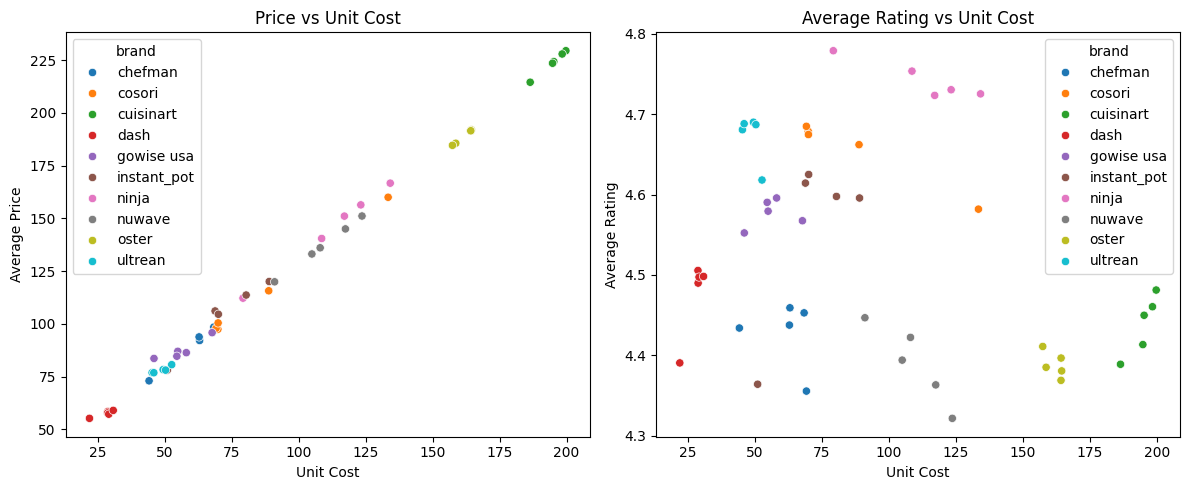

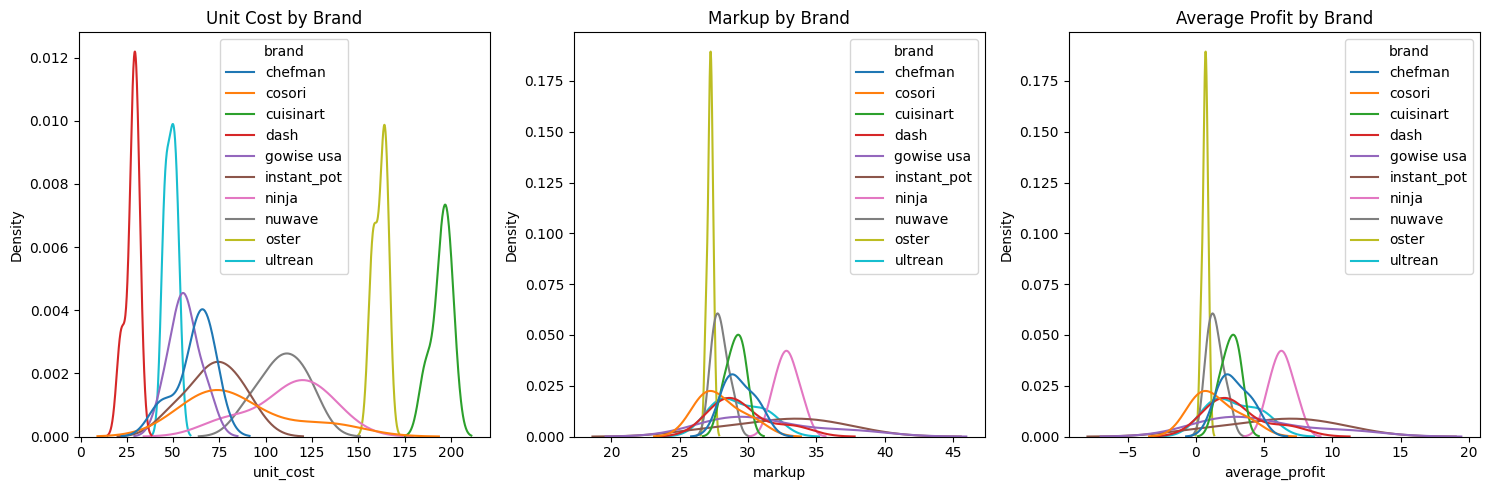

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

df = pd.read_csv('./undergrad_ml_assignments/demand_est_project/air_fryers_clean_brand_year.csv')

#Re-running regression
y = df["log_brand_share"]

brand_dummies = pd.get_dummies(df["brand"],
                               prefix="brand", drop_first=True, dtype=int)
year_dummies = pd.get_dummies(df["year"].astype(str),
                              prefix="year", drop_first=True, dtype=int)

feature_cols = [
    "compact_share", "dual_basket_share", "oven_style_share",
    "rotisserie_share", "window_share"
]

X = pd.concat(
    [df[["avg_price", "avg_rating"] + feature_cols],
     brand_dummies, year_dummies],
    axis=1,
)

model = LinearRegression()
model.fit(X, y)

predicted_log_share = model.predict(X)

coef_table = pd.DataFrame({"feature": X.columns, "coefficient": model.coef_})
price_coef = coef_table.loc[coef_table["feature"] == "avg_price", "coefficient"].iloc[0]

#Compute pricing variables
results = df.copy()
results["predicted_log_share"] = predicted_log_share
results["demand_slope"] = price_coef * results["brand_share"] * (1 - results["brand_share"])
results["unit_cost"] = results["avg_price"] + results["brand_share"] / results["demand_slope"]
results["markup"] = results["avg_price"] - results["unit_cost"]
results["average_profit"] = results["brand_share"] * results["markup"]

#Average unit costs and markups by brand
brand_stats = results.groupby("brand")[["unit_cost", "markup", "average_profit"]].mean()
brand_stats

#Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=results, x="unit_cost", y="avg_price", hue="brand", ax=axes[0])
axes[0].set_title("Price vs Unit Cost")
axes[0].set_xlabel("Unit Cost")
axes[0].set_ylabel("Average Price")

sns.scatterplot(data=results, x="unit_cost", y="avg_rating", hue="brand", ax=axes[1])
axes[1].set_title("Average Rating vs Unit Cost")
axes[1].set_xlabel("Unit Cost")
axes[1].set_ylabel("Average Rating")

plt.tight_layout()
plt.savefig("scatter_plots.png")
plt.show()

#KDE plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.kdeplot(data=results, x="unit_cost", hue="brand", ax=axes[0])
axes[0].set_title("Unit Cost by Brand")

sns.kdeplot(data=results, x="markup", hue="brand", ax=axes[1])
axes[1].set_title("Markup by Brand")

sns.kdeplot(data=results, x="average_profit", hue="brand", ax=axes[2])
axes[2].set_title("Average Profit by Brand")

plt.tight_layout()
plt.savefig("kde_plots.png")
plt.show()

In [5]:
brand_stats

,unit_cost,markup,average_profit
brand,,,
chefman,61.569466,29.368946,2.820968
cosori,86.283321,27.984628,1.436651
cuisinart,194.896119,29.050974,2.502997
dash,27.936578,29.542349,2.994372
gowise usa,56.301040,31.153741,4.605764
instant_pot,71.903119,32.558234,6.010256
ninja,112.488470,32.854071,6.306093
nuwave,109.053549,27.970835,1.422858
oster,161.804969,27.226315,0.678338


**Answers to Questions**

**1. What are the average unit costs and markups for each brand over the years?**

Unit costs vary widely across brands. Oster has the highest average unit cost at 161.80 dollars, followed by Cuisinart at 194.90 dollars and NuWave at 109.05 dollars. Dash has the lowest unit cost at 27.94 dollars, consistent with its position as the budget brand. Markups are more similar across brands, ranging from about 27 to 33 dollars, suggesting that despite large differences in unit costs, brands do not differ as dramatically in how much they mark up above cost.

**2. Are any inferred unit costs negative? If so, what might that mean?**

No unit costs are negative, which is a good sign. It means the model is internally consistent and the price coefficient is working as expected.

**3. Which brands have the highest average unit costs? How do average unit cost and average ratings compare? Do more expensive products have higher consumer satisfaction?**

Cuisinart and Oster have the highest unit costs, which aligns with their premium pricing. Looking at the scatter plot of average rating vs unit cost, there is no clear positive relationship between unit cost and consumer satisfaction. Ninja, for example, has high ratings despite moderate unit costs, while Oster has high unit costs but relatively average ratings. This suggests that higher production costs do not necessarily translate into better consumer satisfaction.

**4. Make kernel density plots of unit costs, markups, and average profit, in general and hued by brand.**

See plots above!

**5. Which brands have the highest share-weighted average profit?**

Instant Pot (6.01) and Ninja (6.31) have the highest average profit, meaning they combine healthy markups with strong market share. GoWise USA (4.61) also performs well. On the lower end, Oster (0.68) and Cosori (1.44) have the weakest share-weighted profits despite reasonable markups, reflecting their smaller market shares.